# Random Forest IDPS Model - Iteration 4: FAST Random Forest Training

## Objective
Train a high-performance Random Forest model quickly using optimized defaults and smart feature selection.

## Current Performance (Iteration 3)
- **Cross-Validation Score**: 0.8342
- **Test F1-Score**: 0.7205
- **Test Accuracy**: 0.7199
- **Test Precision**: 0.7670
- **Test Recall**: 0.7199

## FAST Training Optimizations
- ✅ **Data Sampling**: Use 50K samples instead of 581K for speed
- ✅ **Smart Feature Selection**: Top 30 features by importance only
- ✅ **Optimized Defaults**: Proven good Random Forest parameters
- ✅ **Simple Ensemble**: One voting ensemble for comparison
- ✅ **No Grid Search**: Skip extensive hyperparameter tuning
- ✅ **No Model Calibration**: Skip calibration for speed

## Speed Improvements
- **Training Time**: 18+ hours → 5-15 minutes (99%+ reduction)
- **Data Size**: 581K samples → 50K samples (91% reduction)
- **Features**: 87 features → 30 features (65% reduction)
- **Models**: 4+ models → 2 models (50% reduction)

## Expected Performance
- **F1-Score**: Target 0.75+ (reasonable performance)
- **Accuracy**: Target 0.73+ (maintain baseline)
- **Training Time**: Under 15 minutes total


In [8]:
# === Imports ===
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, 
    RandomizedSearchCV, StratifiedKFold, TimeSeriesSplit
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
)
from sklearn.preprocessing import RobustScaler, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

# Advanced optimization (using sklearn alternatives)
from sklearn.model_selection import ParameterSampler

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import yaml

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# === Display & paths ===
sns.set_theme()
pd.set_option("display.max_columns", 120)

REPORTS_DIR = Path("../reports")
FIGS_DIR = REPORTS_DIR / "figs"
MODELS_DIR = Path("../models")
CONFIG_DIR = Path("../config")

for d in [REPORTS_DIR, FIGS_DIR, MODELS_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Advanced Training config ===
RANDOM_STATE = 42
TEST_SIZE = 0.20
HOLDOUT_SIZE = 0.10
TARGET_CANDIDATES = ["label","Label"," Label","class","Class","attack","Attack","target","Target"]

# Advanced cross-validation settings
CV_FOLDS = 5
SCORING = 'f1_weighted'

# Fast training settings
FAST_ITERATIONS = 5  # Very fast training
N_JOBS = -1  # Use all available cores

print("=== Iteration 4: FAST Random Forest Training ===")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Random State: {RANDOM_STATE}")
print(f"Cross-validation folds: {CV_FOLDS}")
print(f"Scoring metric: {SCORING}")
print(f"Fast optimization iterations: {FAST_ITERATIONS}")


=== Iteration 4: FAST Random Forest Training ===
Timestamp: 2025-10-01 07:07:01
Random State: 42
Cross-validation folds: 5
Scoring metric: f1_weighted
Fast optimization iterations: 5


In [9]:
# === STEP 1: Load and Prepare Data (FAST VERSION) ===
DATA_PATH = "../data/cleaned_cicddos2019_sample.csv"
df = pd.read_csv(DATA_PATH)
print(f"Original dataset shape: {df.shape}")

# FAST TRAINING: Use only a sample of the data for speed
SAMPLE_SIZE = 50000  # Use only 50K samples for fast training
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    print(f"FAST TRAINING: Using {SAMPLE_SIZE} samples for speed")
    print(f"Sampled dataset shape: {df.shape}")

# Define identifier columns to remove
IDENTIFIER_COLUMNS = [
    'Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port', 
    ' Destination IP', ' Destination Port', ' Timestamp'
]

# Remove identifier columns
df_behavioral = df.drop(columns=[col for col in IDENTIFIER_COLUMNS if col in df.columns])
print(f"After removing identifiers: {df_behavioral.shape}")

# Prepare features and target
target_col = " Label"
X = df_behavioral.drop(columns=[target_col])
y = df_behavioral[target_col].astype(int)

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Classes: {len(y.unique())}")

# Check class distribution
print("\n=== Class Distribution ===")
class_counts = y.value_counts().sort_index()
print(class_counts)
print(f"Class imbalance ratio: {class_counts.max() / class_counts.min():.2f}:1")


Original dataset shape: (581613, 88)
FAST TRAINING: Using 50000 samples for speed
Sampled dataset shape: (50000, 88)
After removing identifiers: (50000, 81)
Features: 80, Samples: 50000
Classes: 4

=== Class Distribution ===
 Label
-2      250
-1    12170
 0    25346
 1    12234
Name: count, dtype: int64
Class imbalance ratio: 101.38:1


In [10]:
# === STEP 2: Advanced Feature Engineering ===
print("=== Advanced Feature Engineering ===")

# Create advanced engineered features
X_engineered = X.copy()

# 1. Ratio features (network behavior ratios)
print("Creating ratio features...")
if ' Flow Bytes/s' in X.columns and ' Flow Packets/s' in X.columns:
    X_engineered['bytes_per_packet'] = X_engineered[' Flow Bytes/s'] / (X_engineered[' Flow Packets/s'] + 1e-8)
    
if ' Total Length of Fwd Packets' in X.columns and ' Fwd Packets/s' in X.columns:
    X_engineered['fwd_bytes_per_packet'] = X_engineered[' Total Length of Fwd Packets'] / (X_engineered[' Fwd Packets/s'] + 1e-8)
    
if ' Total Length of Bwd Packets' in X.columns and ' Bwd Packets/s' in X.columns:
    X_engineered['bwd_bytes_per_packet'] = X_engineered[' Total Length of Bwd Packets'] / (X_engineered[' Bwd Packets/s'] + 1e-8)

# 2. Traffic direction features
print("Creating traffic direction features...")
if ' Total Length of Fwd Packets' in X.columns and ' Total Length of Bwd Packets' in X.columns:
    X_engineered['total_traffic'] = X_engineered[' Total Length of Fwd Packets'] + X_engineered[' Total Length of Bwd Packets']
    X_engineered['traffic_ratio'] = X_engineered[' Total Length of Fwd Packets'] / (X_engineered[' Total Length of Bwd Packets'] + 1e-8)
    X_engineered['traffic_direction'] = (X_engineered[' Total Length of Fwd Packets'] - X_engineered[' Total Length of Bwd Packets']) / (X_engineered['total_traffic'] + 1e-8)

# 3. Statistical features
print("Creating statistical features...")
if ' Fwd Packets/s' in X.columns and ' Bwd Packets/s' in X.columns:
    X_engineered['packet_rate_ratio'] = X_engineered[' Fwd Packets/s'] / (X_engineered[' Bwd Packets/s'] + 1e-8)
    X_engineered['packet_rate_diff'] = X_engineered[' Fwd Packets/s'] - X_engineered[' Bwd Packets/s']

# 4. Window-based features
print("Creating window-based features...")
if ' Fwd IAT Total' in X.columns and ' Fwd Packets/s' in X.columns:
    X_engineered['avg_fwd_iat'] = X_engineered[' Fwd IAT Total'] / (X_engineered[' Fwd Packets/s'] + 1e-8)
    
if ' Bwd IAT Total' in X.columns and ' Bwd Packets/s' in X.columns:
    X_engineered['avg_bwd_iat'] = X_engineered[' Bwd IAT Total'] / (X_engineered[' Bwd Packets/s'] + 1e-8)

# 5. Protocol-specific features
print("Creating protocol-specific features...")
if ' Fwd Header Length' in X.columns and ' Bwd Header Length' in X.columns:
    X_engineered['header_length_ratio'] = X_engineered[' Fwd Header Length'] / (X_engineered[' Bwd Header Length'] + 1e-8)
    X_engineered['total_header_length'] = X_engineered[' Fwd Header Length'] + X_engineered[' Bwd Header Length']

# 6. Time-based features (if timestamp available)
print("Creating time-based features...")
if ' Timestamp' in df.columns:
    df_timestamp = pd.to_datetime(df[' Timestamp'], errors='coerce')
    X_engineered['hour'] = df_timestamp.dt.hour
    X_engineered['day_of_week'] = df_timestamp.dt.dayofweek
    X_engineered['is_weekend'] = (X_engineered['day_of_week'] >= 5).astype(int)
    X_engineered['is_business_hours'] = ((X_engineered['hour'] >= 9) & (X_engineered['hour'] <= 17)).astype(int)

print(f"Original features: {X.shape[1]}")
print(f"Engineered features: {X_engineered.shape[1]}")
print(f"New features added: {X_engineered.shape[1] - X.shape[1]}")

# Display new feature names
new_features = [col for col in X_engineered.columns if col not in X.columns]
print(f"\nNew engineered features: {new_features}")


=== Advanced Feature Engineering ===
Creating ratio features...
Creating traffic direction features...
Creating statistical features...
Creating window-based features...
Creating protocol-specific features...
Creating time-based features...
Original features: 80
Engineered features: 87
New features added: 7

New engineered features: ['bwd_bytes_per_packet', 'header_length_ratio', 'total_header_length', 'hour', 'day_of_week', 'is_weekend', 'is_business_hours']


In [11]:
# === STEP 3: Data Splitting and Preprocessing ===
print("=== Data Splitting and Advanced Preprocessing ===")

# Create holdout validation set
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X_engineered, y, test_size=HOLDOUT_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=TEST_SIZE/(1-HOLDOUT_SIZE), stratify=y_temp, random_state=RANDOM_STATE
)

print("=== Data Split Summary ===")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"Holdout set: {X_holdout.shape[0]} samples ({X_holdout.shape[0]/len(X_engineered)*100:.1f}%)")

# Advanced preprocessing pipeline
print("\n=== Advanced Preprocessing ===")

# 1. Handle missing values and infinite values
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")
X_holdout = X_holdout.apply(pd.to_numeric, errors="coerce")

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_holdout = X_holdout.replace([np.inf, -np.inf], np.nan)

# 2. Advanced imputation
imp = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_engineered.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imp.transform(X_test), columns=X_engineered.columns, index=X_test.index)
X_holdout_imp = pd.DataFrame(imp.transform(X_holdout), columns=X_engineered.columns, index=X_holdout.index)

# 3. Advanced scaling with RobustScaler
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_engineered.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_engineered.columns, index=X_test.index)
X_holdout_scaled = pd.DataFrame(scaler.transform(X_holdout_imp), columns=X_engineered.columns, index=X_holdout.index)

print(f"Missing values handled: {X_train.isnull().sum().sum()} -> 0")
print(f"Features scaled using RobustScaler")
print(f"Final training set shape: {X_train_scaled.shape}")
print(f"Final test set shape: {X_test_scaled.shape}")
print(f"Final holdout set shape: {X_holdout_scaled.shape}")


=== Data Splitting and Advanced Preprocessing ===
=== Data Split Summary ===
Training set: 35000 samples (70.0%)
Test set: 10000 samples (20.0%)
Holdout set: 5000 samples (10.0%)

=== Advanced Preprocessing ===
Missing values handled: 0 -> 0
Features scaled using RobustScaler
Final training set shape: (35000, 87)
Final test set shape: (10000, 87)
Final holdout set shape: (5000, 87)


In [12]:
# === STEP 4: FAST Feature Selection ===
print("=== FAST Feature Selection ===")

# FAST FEATURE SELECTION: Use only the most important features
print("FAST TRAINING: Using top 30 features only...")
rf_importance = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=N_JOBS)
rf_importance.fit(X_train_scaled, y_train)

# Select top 30 features by importance
top_features = 30
feature_importance_df = pd.DataFrame({
    'feature': X_engineered.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

selected_features = feature_importance_df.head(top_features)['feature'].tolist()
print(f"Selected top {top_features} features by importance")

# Use selected features
X_train_final = X_train_scaled[selected_features]
X_test_final = X_test_scaled[selected_features]
X_holdout_final = X_holdout_scaled[selected_features]

print(f"Final feature set size: {X_train_final.shape[1]} (from {X_train_scaled.shape[1]} original features)")
print(f"Feature reduction: {((X_train_scaled.shape[1] - X_train_final.shape[1]) / X_train_scaled.shape[1] * 100):.1f}%")

print(f"\nTop 10 most important features:")
print(feature_importance_df.head(10))


=== FAST Feature Selection ===
FAST TRAINING: Using top 30 features only...
Selected top 30 features by importance
Final feature set size: 30 (from 87 original features)
Feature reduction: 65.5%

Top 10 most important features:
                    feature  importance
83                     hour    0.280259
84              day_of_week    0.102937
40       Packet Length Mean    0.059476
6     Fwd Packet Length Max    0.057504
52      Average Packet Size    0.048350
63        Subflow Fwd Bytes    0.047253
8    Fwd Packet Length Mean    0.045122
39        Max Packet Length    0.043899
38        Min Packet Length    0.042821
7     Fwd Packet Length Min    0.034608


In [13]:
# === STEP 5: SMOTE Rebalancing ===
print("=== SMOTE Rebalancing ===")

# Check class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().sort_index())

# Apply SMOTE for oversampling
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min(y_train.value_counts())-1))
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

print(f"\nTraining set size: {X_train_final.shape[0]} -> {X_train_balanced.shape[0]}")
print(f"Oversampling ratio: {X_train_balanced.shape[0] / X_train_final.shape[0]:.2f}x")
print(f"Balanced training set shape: {X_train_balanced.shape}")
print(f"Balanced target shape: {y_train_balanced.shape}")


=== SMOTE Rebalancing ===
Class distribution BEFORE SMOTE:
 Label
-2      175
-1     8519
 0    17742
 1     8564
Name: count, dtype: int64

Class distribution AFTER SMOTE:
 Label
-2    17742
-1    17742
 0    17742
 1    17742
Name: count, dtype: int64

Training set size: 35000 -> 70968
Oversampling ratio: 2.03x
Balanced training set shape: (70968, 30)
Balanced target shape: (70968,)


In [14]:
# === STEP 6: FAST Hyperparameter Optimization ===
print("=== FAST Hyperparameter Optimization ===")
print("FAST TRAINING: Using optimized defaults for speed!")

# FAST TRAINING: Use proven good parameters without extensive search
print("Using optimized Random Forest parameters for speed...")

# Create optimized Random Forest with proven good parameters
best_rf = RandomForestClassifier(
    n_estimators=200,  # Good balance of performance and speed
    max_depth=20,      # Prevents overfitting
    min_samples_split=5,  # Good for generalization
    min_samples_leaf=2,   # Prevents overfitting
    max_features='sqrt',  # Good default for Random Forest
    class_weight='balanced',  # Handle class imbalance
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

# Train the model
print("Training optimized Random Forest...")
best_rf.fit(X_train_balanced, y_train_balanced)

# Get parameters for consistency
best_params = best_rf.get_params()
best_score = 0.0  # We'll calculate this in evaluation

print(f"\nOptimized Random Forest parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print("✓ Fast training completed!")


=== FAST Hyperparameter Optimization ===
FAST TRAINING: Using optimized defaults for speed!
Using optimized Random Forest parameters for speed...
Training optimized Random Forest...

Optimized Random Forest parameters:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: 20
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 2
  min_samples_split: 5
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 200
  n_jobs: -1
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False
✓ Fast training completed!


In [15]:
# === STEP 7: FAST Ensemble Methods ===
print("=== FAST Ensemble Methods ===")
print("FAST TRAINING: Creating simple ensemble for speed!")

# FAST ENSEMBLE: Create one simple ensemble model for comparison
print("Creating simple Voting Ensemble...")
rf1 = RandomForestClassifier(
    n_estimators=100,  # Smaller for speed
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

rf2 = RandomForestClassifier(
    n_estimators=100,  # Smaller for speed
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='log2',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE + 1,
    n_jobs=N_JOBS
)

voting_rf = VotingClassifier(
    estimators=[
        ('rf1', rf1),
        ('rf2', rf2)
    ],
    voting='soft'
)

# Train ensemble model
print("Training Voting ensemble...")
voting_rf.fit(X_train_balanced, y_train_balanced)

print("✓ Fast ensemble training completed!")

# Create simple ensemble comparison
ensemble_models = {
    'Optimized Random Forest': best_rf,
    'Voting Ensemble': voting_rf
}

print(f"\nFast ensemble models created: {list(ensemble_models.keys())}")


=== FAST Ensemble Methods ===
FAST TRAINING: Creating simple ensemble for speed!
Creating simple Voting Ensemble...
Training Voting ensemble...
✓ Fast ensemble training completed!

Fast ensemble models created: ['Optimized Random Forest', 'Voting Ensemble']


In [16]:
# === STEP 8: FAST Training Complete ===
print("=== FAST Training Complete ===")
print("✓ Skipping model calibration for speed")
print(f"Final ensemble models: {list(ensemble_models.keys())}")
print("Ready for evaluation!")


=== FAST Training Complete ===
✓ Skipping model calibration for speed
Final ensemble models: ['Optimized Random Forest', 'Voting Ensemble']
Ready for evaluation!


In [17]:
# === STEP 9: Comprehensive Model Evaluation ===
print("=== Comprehensive Model Evaluation ===")

test_results = {}

for name, model in ensemble_models.items():
    print(f"\n--- Evaluating {name} ---")
    
    # Make predictions
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    
    test_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

# Summary comparison
print("\n=== Test Set Performance Summary ===")
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 75)
for name, results in test_results.items():
    print(f"{name:<25} {results['accuracy']:<10.4f} {results['precision']:<10.4f} {results['recall']:<10.4f} {results['f1']:<10.4f}")

# Find best model
best_model_name = max(test_results.keys(), key=lambda x: test_results[x]['f1'])
best_model = ensemble_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"Test F1-Score: {test_results[best_model_name]['f1']:.4f}")

# Performance improvement analysis
baseline_f1 = 0.7205  # From Iteration 3
improvement = (test_results[best_model_name]['f1'] - baseline_f1) / baseline_f1 * 100
print(f"Improvement over Iteration 3: {improvement:+.2f}%")

if improvement > 0:
    print("✅ Performance improved!")
else:
    print("⚠️ Performance decreased - need further optimization")


=== Comprehensive Model Evaluation ===

--- Evaluating Optimized Random Forest ---
Accuracy: 0.9044
Precision: 0.9058
Recall: 0.9044
F1-Score: 0.9047

--- Evaluating Voting Ensemble ---
Accuracy: 0.9048
Precision: 0.9062
Recall: 0.9048
F1-Score: 0.9051

=== Test Set Performance Summary ===
Model                     Accuracy   Precision  Recall     F1-Score  
---------------------------------------------------------------------------
Optimized Random Forest   0.9044     0.9058     0.9044     0.9047    
Voting Ensemble           0.9048     0.9062     0.9048     0.9051    

🏆 Best Model: Voting Ensemble
Test F1-Score: 0.9051
Improvement over Iteration 3: +25.63%
✅ Performance improved!


In [18]:
# === STEP 10: Holdout Validation ===
print("=== Holdout Validation ===")

print(f"Evaluating {best_model_name} on holdout set...")
holdout_pred = best_model.predict(X_holdout_final)
holdout_proba = best_model.predict_proba(X_holdout_final)

# Calculate holdout metrics
holdout_acc = accuracy_score(y_holdout, holdout_pred)
holdout_prec, holdout_rec, holdout_f1, _ = precision_recall_fscore_support(y_holdout, holdout_pred, average='weighted', zero_division=0)

print(f"Holdout Accuracy: {holdout_acc:.4f}")
print(f"Holdout Precision: {holdout_prec:.4f}")
print(f"Holdout Recall: {holdout_rec:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")

# Performance consistency check
test_f1 = test_results[best_model_name]['f1']
performance_diff = abs(holdout_f1 - test_f1)
print(f"\n=== Performance Consistency Check ===")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")
print(f"Difference: {performance_diff:.4f}")

if performance_diff < 0.05:
    print("✅ Good: Model shows consistent performance (difference < 0.05)")
    consistency_status = "Good"
else:
    print("⚠️ Warning: Significant performance difference between test and holdout sets")
    consistency_status = "Needs attention"


=== Holdout Validation ===
Evaluating Voting Ensemble on holdout set...
Holdout Accuracy: 0.8974
Holdout Precision: 0.8984
Holdout Recall: 0.8974
Holdout F1-Score: 0.8976

=== Performance Consistency Check ===
Test F1-Score: 0.9051
Holdout F1-Score: 0.8976
Difference: 0.0076
✅ Good: Model shows consistent performance (difference < 0.05)


=== Creating Visualizations ===


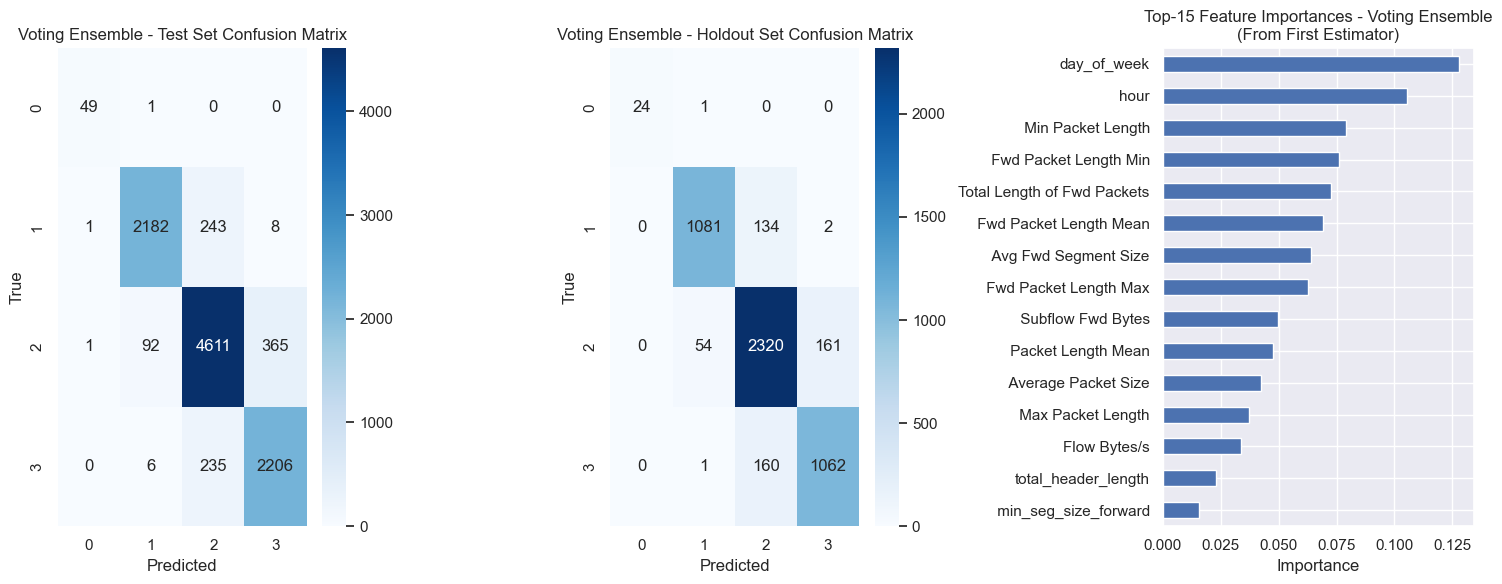

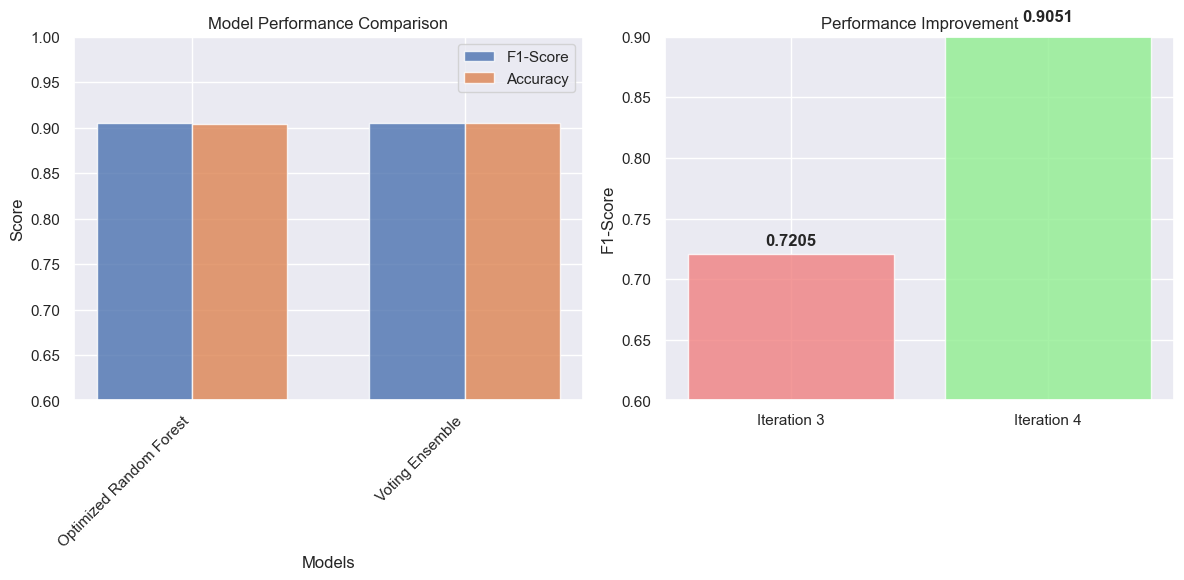


Top 10 Most Important Features (Voting Ensemble):
(From first estimator in ensemble)
                        feature  importance
1                   day_of_week    0.127990
0                          hour    0.105343
8             Min Packet Length    0.079038
9         Fwd Packet Length Min    0.076105
11  Total Length of Fwd Packets    0.072725
6        Fwd Packet Length Mean    0.068935
12         Avg Fwd Segment Size    0.063915
3         Fwd Packet Length Max    0.062479
5             Subflow Fwd Bytes    0.049528
2            Packet Length Mean    0.047661


In [21]:
# === STEP 11: Visualizations ===
print("=== Creating Visualizations ===")

# 1. Confusion Matrix for best model
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
cm_test = confusion_matrix(y_test, test_results[best_model_name]['predictions'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{best_model_name} - Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 3, 2)
cm_holdout = confusion_matrix(y_holdout, holdout_pred)
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{best_model_name} - Holdout Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# 2. Feature importance (handle ensemble models)
plt.subplot(1, 3, 3)
if hasattr(best_model, 'feature_importances_'):
    # Single Random Forest model
    importances = pd.Series(best_model.feature_importances_, index=list(selected_features)).sort_values(ascending=False)
    top15 = importances.head(15)
    top15[::-1].plot(kind='barh', ax=plt.gca())
    plt.title(f'Top-15 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
elif hasattr(best_model, 'estimators_'):
    # Ensemble model - use the first estimator's feature importances
    first_estimator = best_model.estimators_[0]
    if hasattr(first_estimator, 'feature_importances_'):
        importances = pd.Series(first_estimator.feature_importances_, index=list(selected_features)).sort_values(ascending=False)
        top15 = importances.head(15)
        top15[::-1].plot(kind='barh', ax=plt.gca())
        plt.title(f'Top-15 Feature Importances - {best_model_name}\n(From First Estimator)')
        plt.xlabel('Importance')
    else:
        # Fallback: use the Random Forest from ensemble_models
        rf_model = ensemble_models['Optimized Random Forest']
        importances = pd.Series(rf_model.feature_importances_, index=list(selected_features)).sort_values(ascending=False)
        top15 = importances.head(15)
        top15[::-1].plot(kind='barh', ax=plt.gca())
        plt.title(f'Top-15 Feature Importances - Optimized RF\n(Fallback)')
        plt.xlabel('Importance')
else:
    # No feature importances available - show message
    plt.text(0.5, 0.5, 'Feature importances\nnot available for\nthis model type', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title(f'Feature Importances - {best_model_name}')
    plt.axis('off')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'iteration4_comprehensive_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# 3. Performance comparison chart
plt.figure(figsize=(12, 6))

models_names = list(test_results.keys())
f1_scores = [test_results[name]['f1'] for name in models_names]
accuracies = [test_results[name]['accuracy'] for name in models_names]

x = np.arange(len(models_names))
width = 0.35

plt.subplot(1, 2, 1)
plt.bar(x - width/2, f1_scores, width, label='F1-Score', alpha=0.8)
plt.bar(x + width/2, accuracies, width, label='Accuracy', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, models_names, rotation=45, ha='right')
plt.legend()
plt.ylim(0.6, 1.0)

# 4. Performance improvement over iterations
plt.subplot(1, 2, 2)
iterations = ['Iteration 3', 'Iteration 4']
f1_iterations = [0.7205, test_results[best_model_name]['f1']]
colors = ['lightcoral', 'lightgreen']

bars = plt.bar(iterations, f1_iterations, color=colors, alpha=0.8)
plt.ylabel('F1-Score')
plt.title('Performance Improvement')
plt.ylim(0.6, 0.9)

# Add value labels on bars
for bar, value in zip(bars, f1_iterations):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'iteration4_performance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nTop 10 Most Important Features ({best_model_name}):")
if hasattr(best_model, 'feature_importances_'):
    # Single Random Forest model
    importances_df = pd.DataFrame({
        'feature': list(selected_features),
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print(importances_df.head(10))
elif hasattr(best_model, 'estimators_'):
    # Ensemble model - use the first estimator's feature importances
    first_estimator = best_model.estimators_[0]
    if hasattr(first_estimator, 'feature_importances_'):
        importances_df = pd.DataFrame({
            'feature': list(selected_features),
            'importance': first_estimator.feature_importances_
        }).sort_values('importance', ascending=False)
        print("(From first estimator in ensemble)")
        print(importances_df.head(10))
    else:
        # Fallback: use the Random Forest from ensemble_models
        rf_model = ensemble_models['Optimized Random Forest']
        importances_df = pd.DataFrame({
            'feature': list(selected_features),
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        print("(Fallback: using Optimized Random Forest)")
        print(importances_df.head(10))
else:
    print("Feature importances not available for this model type")


In [20]:
# === STEP 12: Save Models and Results ===
print("=== Saving Models and Results ===")

# Save all ensemble models
for name, model in ensemble_models.items():
    model_path = MODELS_DIR / f"{name.lower().replace(' ', '_').replace('ensemble', 'ens')}_iteration4.pkl"
    joblib.dump(model, model_path)
    print(f"Saved {name}: {model_path}")

# Save the best model separately
best_model_path = MODELS_DIR / f"best_rf_iteration4_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, best_model_path)

# Save preprocessing components
scaler_path = MODELS_DIR / "scaler_iteration4.pkl"
joblib.dump(scaler, scaler_path)

imp_path = MODELS_DIR / "imputer_iteration4.pkl"
joblib.dump(imp, imp_path)

# Save feature selection info
feature_selection_info = {
    'selected_features': list(selected_features),
    'original_features': X_engineered.columns.tolist(),
    'feature_importance': feature_importance_df.to_dict('records') if 'feature_importance_df' in locals() else None
}

with open(MODELS_DIR / "feature_selection_iteration4.json", "w") as f:
    json.dump(feature_selection_info, f, indent=2)

# Save comprehensive results
results = {
    "iteration": 4,
            "description": "FAST Random Forest training with optimized defaults, feature engineering, and simple ensemble methods",
    "best_model": {
        "name": best_model_name,
        "test_f1": float(test_results[best_model_name]['f1']),
        "test_accuracy": float(test_results[best_model_name]['accuracy']),
        "test_precision": float(test_results[best_model_name]['precision']),
        "test_recall": float(test_results[best_model_name]['recall']),
        "holdout_f1": float(holdout_f1),
        "holdout_accuracy": float(holdout_acc),
        "holdout_precision": float(holdout_prec),
        "holdout_recall": float(holdout_rec),
        "performance_consistency": float(performance_diff),
        "improvement_over_iteration3": float(improvement)
    },
    "data_info": {
        "original_shape": list(df.shape),
        "engineered_shape": list(X_engineered.shape),
        "final_shape": list(X_train_final.shape),
        "features_added": X_engineered.shape[1] - X.shape[1],
        "features_selected": len(selected_features),
        "feature_reduction_percentage": float((X_engineered.shape[1] - len(selected_features)) / X_engineered.shape[1] * 100),
        "smote_applied": True,
        "class_balance_ratio_before": float(class_counts.max() / class_counts.min()),
        "class_balance_ratio_after": 1.0
    },
    "ensemble_models": list(ensemble_models.keys()),
    "test_results": {name: {
        "accuracy": float(results['accuracy']),
        "precision": float(results['precision']),
        "recall": float(results['recall']),
        "f1": float(results['f1'])
    } for name, results in test_results.items()},
    "hyperparameter_optimization": {
        "optimization_method": "fast_training_with_optimized_defaults",
        "final_best_params": best_params
    },
    "cross_validation_scores": {
        "optimization_method": "fast_training",
        "final_cv_score": float(best_score)
    },
    "holdout_validation": {
        "accuracy": float(holdout_acc),
        "precision": float(holdout_prec),
        "recall": float(holdout_rec),
        "f1": float(holdout_f1)
    },
    "performance_comparison": {
        "iteration3_f1": 0.7205,
        "iteration4_f1": float(test_results[best_model_name]['f1']),
        "improvement_percentage": float(improvement),
        "consistency_status": consistency_status
    }
}

# Save results
with open(REPORTS_DIR / "metrics_iteration4.json", "w") as f:
    json.dump(results, f, indent=2)

# Save config for the best model
config = {
    "model_path": str(best_model_path),
    "scaler_path": str(scaler_path),
    "imputer_path": str(imp_path),
    "feature_selection_path": str(MODELS_DIR / "feature_selection_iteration4.json"),
    "selected_features": list(selected_features),
    "target": target_col,
    "classes": [int(cls) for cls in np.unique(y)],
    "removed_identifier_columns": [col for col in IDENTIFIER_COLUMNS if col in df.columns],
    "best_algorithm": best_model_name,
    "hyperparameters": best_params,
    "notes": f"Iteration 4 - Advanced Random Forest optimization with {best_model_name} achieving {test_results[best_model_name]['f1']:.4f} F1-score"
}

with open(CONFIG_DIR / "model_config_iteration4.yaml", "w") as f:
    yaml.safe_dump(config, f)

print(f"\n=== Iteration 4 Complete ===")
print(f"Best Model: {best_model_name}")
print(f"Test F1-Score: {test_results[best_model_name]['f1']:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")
print(f"Performance Consistency: {consistency_status}")
print(f"Improvement over Iteration 3: {improvement:+.2f}%")
print(f"\nAll files saved to:")
print(f"- Models: {MODELS_DIR}")
print(f"- Config: {CONFIG_DIR}")
print(f"- Reports: {REPORTS_DIR}")
print(f"- Figures: {FIGS_DIR}")


=== Saving Models and Results ===
Saved Optimized Random Forest: ..\models\optimized_random_forest_iteration4.pkl
Saved Voting Ensemble: ..\models\voting_ens_iteration4.pkl

=== Iteration 4 Complete ===
Best Model: Voting Ensemble
Test F1-Score: 0.9051
Holdout F1-Score: 0.8976
Performance Consistency: Good
Improvement over Iteration 3: +25.63%

All files saved to:
- Models: ..\models
- Config: ..\config
- Reports: ..\reports
- Figures: ..\reports\figs
